## Avancerade Pandas-mönster & mer prestandatänk

### Agenda

1. **Avancerade Pandas-mönster**:
   - `query` och `eval` för filtrering och nya kolumner
   - Method chaining och `assign`
   - Pipelines med `pipe`
   - `groupby.transform` jämfört med `groupby.agg`
   - Fönsterfunktioner: `shift`, `diff`, `rolling`
2. **Prestanda, del II**:
   - Lite mer om minne, `copy()` och chunkad läsning
3. **Lite om vad som finns efter Pandas** – bara namn-droppning:
   - Polars, DuckDB, Dask, Spark, databaser…
   - När man brukar börja titta på dem

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ställ in så att Pandas skriver ut lite fler kolumner/kolumnbredd
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

---
## 1. Avancerade Pandas-mönster

I det här avsnittet tittar vi på mönster som du **redan nästan kan**, men där vi gör koden:

- mer **läsbar**
- mer **kompakt**
- mer lik en **datapipeline**

Vi börjar med ett litet **syntetiskt sälj-dataset** som vi kan återanvända i flera exempel.


In [2]:
# Skapa ett litet syntetiskt "sales"-dataset
products = ["Laptop", "Phone", "Tablet", "Headphones", "Monitor"]
countries = ["SE", "NO", "DK", "FI", "DE"]

n_rows = 200

sales_df = pd.DataFrame({
                            "OrderID": range(1, n_rows + 1),
                            "ProductName": [random.choice(products) for _ in range(n_rows)],
                            "Country": [random.choice(countries) for _ in range(n_rows)],
                            "Price": [random.randint(500, 14999) for _ in range(n_rows)],   
                            "Quantity": [random.randint(1, 4) for _ in range(n_rows)],
                            "OrderDate": pd.to_datetime("2025-01-01") + pd.to_timedelta([random.randint(0, 89) for _ in range(n_rows)], unit="D"),
})

sales_df.head()

,OrderID,ProductName,Country,Price,Quantity,OrderDate
0,1,Monitor,FI,10315,2,2025-03-08
1,2,Tablet,SE,7823,1,2025-03-02
2,3,Monitor,FI,1380,4,2025-02-13
3,4,Laptop,FI,13159,2,2025-03-19
4,5,Laptop,NO,892,3,2025-03-17


---

### 1.1 `query` och `eval` – snyggare uttryck

Innan vi går in på method chaining ska vi titta på två verktyg som ofta dyker upp där:

- `query` – för att filtrera rader med en liten sträng
- `eval` – för att skapa/uppdatera kolumner med ett uttryck

#### `query` för filtrering

`query` låter dig skriva filter som en liten sträng, vilket ibland blir mer läsbart än många `&` och `|`.


In [3]:
# Filter: svenska ordrar med pris > 5000 och kvantitet minst 2
filt1 = sales_df.query("Country == 'SE' and Price > 5000 and Quantity >= 2")
filt1.head()

,OrderID,ProductName,Country,Price,Quantity,OrderDate
20,21,Monitor,SE,14583,3,2025-02-28
24,25,Phone,SE,6834,3,2025-01-05
25,26,Headphones,SE,8310,2,2025-02-01
52,53,Laptop,SE,7787,2,2025-03-07
59,60,Phone,SE,10507,3,2025-02-16


Detta motsvarar ungefär:

```python
sales_df[
    (sales_df["Country"] == "SE")
    & (sales_df["Price"] > 5000)
    & (sales_df["Quantity"] >= 2)
]
```

Båda varianterna är korrekta – välj den du tycker är tydligast.

#### `eval` för nya kolumner

`eval` låter dig beräkna uttryck på kolumner med en strängsyntax:

In [4]:
# Lägg till en revenue-kolumn med eval
eval_df = sales_df.copy()
eval_df = eval_df.eval("revenue = Price * Quantity")
eval_df.head()

,OrderID,ProductName,Country,Price,Quantity,OrderDate,revenue
0,1,Monitor,FI,10315,2,2025-03-08,20630
1,2,Tablet,SE,7823,1,2025-03-02,7823
2,3,Monitor,FI,1380,4,2025-02-13,5520
3,4,Laptop,FI,13159,2,2025-03-19,26318
4,5,Laptop,NO,892,3,2025-03-17,2676


> I vissa fall kan `query`/`eval` också vara snabbare än motsvarande "vanliga" kod, men den största vinsten är ofta **läsbarhet**.


---
### 1.2 Intro till: `.agg` och `lambda`

#### `.agg` – aggregera värden

`agg` låter dig räkna ut sammanfattande mått, t.ex. medelvärde och maxvärde för en kolumn:

In [5]:
# Enkel .agg på en Series

sales_df["Price"].agg(["mean"])

mean    7448.08
Name: Price, dtype: float64

In [6]:
# Enkel .agg på en Series
sales_df["Price"].agg(["mean", "max", "sum"])

mean       7448.08
max       14937.00
sum     1489616.00
Name: Price, dtype: float64

Vi kan också använda `agg` efter en `groupby` för att ge namn åt beräknade kolumner:

In [7]:
sales_df.groupby("Country").agg(
    total_sales=("Price", "sum"),
    avg_quantity=("Quantity", "mean"),
)

,total_sales,avg_quantity
Country,,
DE,189169,2.406250
DK,288184,2.307692
FI,348786,2.681818
NO,300310,2.775000
SE,363167,2.488889


Där t.ex. `total_sales=("Price", "sum")` betyder:

- skapa en kolumn som heter `total_sales`
- beräkna den genom att ta `sum` av kolumnen `"Price"` inom varje grupp.

#### `lambda` – små funktioner "i farten"

En `lambda` är ett sätt att skriva en **liten funktion på en rad**.

Med vanlig funktion:

In [8]:
def add_vat(price):
    return price * 1.25

sales_df["Price_with_vat_def"] = sales_df["Price"].apply(add_vat)

Samma sak med lambda:

In [9]:
sales_df["Price_with_vat_lambda"] = sales_df["Price"].apply(lambda x: x * 1.25)

sales_df.head()

,OrderID,ProductName,Country,Price,Quantity,OrderDate,Price_with_vat_def,Price_with_vat_lambda
0,1,Monitor,FI,10315,2,2025-03-08,12893.75,12893.75
1,2,Tablet,SE,7823,1,2025-03-02,9778.75,9778.75
2,3,Monitor,FI,1380,4,2025-02-13,1725.00,1725.00
3,4,Laptop,FI,13159,2,2025-03-19,16448.75,16448.75
4,5,Laptop,NO,892,3,2025-03-17,1115.00,1115.00


`lambda x: x * 1.25` betyder ungefär "en funktion med ett argument `x` som returnerar `x * 1.25`".


---
### 1.3 Method chaining & `assign`

Ofta skriver vi Pandas-kod steg för steg, t.ex. så här:

In [10]:
# Klassisk "steg-för-steg"-kod
df = sales_df.copy()

# 1. Byt namn på kolumn
df = df.rename(columns={"ProductName": "product"})

# 2. Filtrera bort orimliga priser (<= 0)
df = df[df["Price"] > 0]

# 3. Räkna ut intäkt per rad
df["revenue"] = df["Price"] * df["Quantity"]

# 4. Summera intäkter per produkt
result_step_by_step = df.groupby("product")["revenue"].sum()

result_step_by_step

product
Headphones    721844
Laptop        726376
Monitor       820902
Phone         746399
Tablet        736076
Name: revenue, dtype: int64

Det här funkar jättebra, men blir snabbt långt när vi lägger till många steg.

Med **method chaining** låter vi i stället `DataFrame` flöda genom en kedja av metoder. Det gör det lättare att läsa processen uppifrån och ned.

Vi använder främst:

- `rename` för att byta kolumnnamn
- `query` för filtrering
- `assign` för att lägga till nya kolumner
- `groupby(..).agg(..)` för sammanställning


In [11]:
# Samma logik, men med method chaining
result_chained = (
    sales_df
    .rename(columns={"ProductName": "product"})
    .query("Price > 0")  # läsbar filtrering
    .assign(revenue=lambda d: d["Price"] * d["Quantity"])
    .groupby("product", as_index=False)
    .agg(total_revenue=("revenue", "sum"),
         avg_price=("Price", "mean"))
)

result_chained

,product,total_revenue,avg_price
0,Headphones,721844,7077.102564
1,Laptop,726376,8930.200000
2,Monitor,820902,7625.181818
3,Phone,746399,7505.702703
4,Tablet,736076,6396.288889


---
### 1.4 `pipe` och enkla pipelines

När kedjan blir längre kan det vara skönt att dela upp logiken i **små funktioner** som var och en gör en sak, och sedan koppla ihop dem med `pipe`.

Tanken med `pipe` är:

> Ta en DataFrame → skicka in den i en funktion → få ut en ny DataFrame → fortsätt kedjan.

In [12]:
def filter_positive_price(df):
    """Filtrera bort rader med pris <= 0."""
    return df[df["Price"] > 0]


def add_revenue(df):
    """Lägg till en revenue-kolumn (Price * Quantity)."""
    df = df.copy()
    df["revenue"] = df["Price"] * df["Quantity"]
    return df


def aggregate_by_product(df):
    """Summera intäkter per produkt."""
    return (
        df.groupby("ProductName", as_index=False)
          .agg(total_revenue=("revenue", "sum"),
               total_quantity=("Quantity", "sum"))
    )

In [13]:
# Bygga en pipeline med pipe
pipeline_result_df = (
     sales_df
    .pipe(filter_positive_price)
    .pipe(add_revenue)
    .pipe(aggregate_by_product)
)

pipeline_result_df

,ProductName,total_revenue,total_quantity
0,Headphones,721844,106
1,Laptop,726376,80
2,Monitor,820902,105
3,Phone,746399,99
4,Tablet,736076,118


Fördelar med att använda `pipe` och små funktioner:

- Varje funktion gör **en tydlig sak**.
- Lättare att återanvända samma steg i andra analyser.
- Koden liknar ett **flöde**: inläsning → filtrering → beräkning → aggregering.

> **Tips:** Du kan börja med vanlig "steg-för-steg"-kod, och när du märker att du gör samma sak på flera ställen – bryt ut det till en funktion och använd `pipe`.

---
### 1.5 Fönsterfunktioner: `shift`, `diff`, `rolling`

Låt oss skapa en enkel tidsserie: daglig "site visits" (t.ex. antal besök på en webbsida).


In [14]:
# Skapa en syntetisk tidsserie med dagliga värden
dates = pd.date_range("2024-01-01", periods=60, freq="D")

# Vi bygger en "random walk" med Python's random.gauss
visits = []
value = 100
for _ in range(len(dates)):
    value += int(random.gauss(0.5, 5))  # slumpmässig förändring
    visits.append(value)

traffic_df = pd.DataFrame({"date": dates, "visits": visits})
traffic_df.head()

,date,visits
0,2024-01-01,99
1,2024-01-02,110
2,2024-01-03,116
3,2024-01-04,121
4,2024-01-05,124


Vi sorterar på datum (bra vana) och använder tre viktiga metoder:

- `.shift(n)` – flyttar värden upp/ned (t.ex. gårdagens värde)
- `.diff()` – skillnad mot föregående rad
- `.rolling(window)` – "rörligt fönster", t.ex. 7-dagars medelvärde


In [15]:
traffic_df = traffic_df.sort_values("date").reset_index(drop=True)

traffic_df["visits_prev_day"] = traffic_df["visits"].shift(1)
traffic_df["change_from_prev"] = traffic_df["visits"].diff()
traffic_df["visits_7d_mean"] = traffic_df["visits"].rolling(7).mean()

traffic_df.head(10)

,date,visits,visits_prev_day,change_from_prev,visits_7d_mean
0,2024-01-01,99,NaN,NaN,NaN
1,2024-01-02,110,99.0,11.0,NaN
2,2024-01-03,116,110.0,6.0,NaN
3,2024-01-04,121,116.0,5.0,NaN
4,2024-01-05,124,121.0,3.0,NaN
5,2024-01-06,128,124.0,4.0,NaN
6,2024-01-07,133,128.0,5.0,118.714286
7,2024-01-08,136,133.0,3.0,124.000000
8,2024-01-09,135,136.0,-1.0,127.571429
9,2024-01-10,138,135.0,3.0,130.714286


Vi kan också göra en enkel plot för att se originalserien och 7-dagarsmedelvärdet:

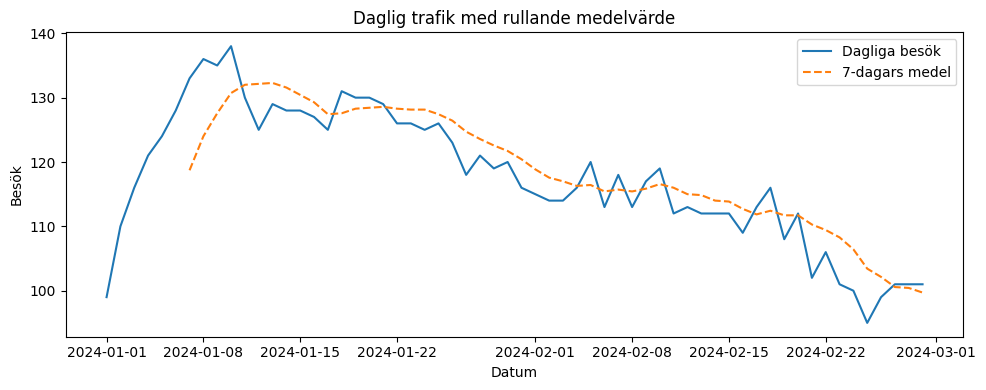

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(traffic_df["date"], traffic_df["visits"], label="Dagliga besök")
plt.plot(traffic_df["date"], traffic_df["visits_7d_mean"], label="7-dagars medel", linestyle="--")
plt.xlabel("Datum")
plt.ylabel("Besök")
plt.title("Daglig trafik med rullande medelvärde")
plt.legend()
plt.tight_layout()
plt.show()

> **Reflektion:** Fönsterfunktioner är väldigt användbara för tidsserier – du kan t.ex. jämna ut brus, räkna förändringar, eller jämföra mot gårdagens/förra veckans värden.


---
## 2. Prestanda i Pandas – Del II

Du har redan sett att:

- `for`-loopar över rader är långsamma
- `iterrows()` och `apply(axis=1)` ofta är betydligt långsammare än vektoriserade operationer

Nu tittar vi på ytterligare tips på minneseffektivisering.


---

### 2.1 Datatyper

#### Viktigt att använda lämpligast datatyp baserat på behov

In [17]:
# Titta på unika länder
sales_df["Country"].value_counts()

Country
SE    45
FI    44
NO    40
DK    39
DE    32
Name: count, dtype: int64

In [18]:
# Gör om Country till category
sales_df_cat = sales_df.copy()
sales_df_cat["Country"] = sales_df_cat["Country"].astype("category")

sales_df_cat.dtypes

OrderID                           int64
ProductName                      object
Country                        category
Price                             int64
Quantity                          int64
OrderDate                datetime64[ns]
Price_with_vat_def              float64
Price_with_vat_lambda           float64
dtype: object

`category`-kolumner:

- tar mindre plats i minnet
- kan ge snabbare groupby/join i vissa fall

---
### 2.2 Minne, `copy()` och chunkad läsning

#### a) Hur mycket minne använder en DataFrame?

Vi har tidigare sett hur man evaluera minnesanvändning per kolumn med `memory_usage`:

In [19]:
sales_df.memory_usage(deep=True)

Index                      132
OrderID                   1600
ProductName              11163
Country                  10200
Price                     1600
Quantity                  1600
OrderDate                 1600
Price_with_vat_def        1600
Price_with_vat_lambda     1600
dtype: int64

In [20]:
total_bytes = sales_df.memory_usage(deep=True).sum()
total_mb = round(total_bytes / (1024 ** 2), 3)
print(f"Total minnesanvändning för sales_df: {total_mb} MB")

Total minnesanvändning för sales_df: 0.03 MB


> `memory_usage` ger antal **byte**. Vi delar med `1024 ** 2` för att få **megabyte (MB)**.

#### b) `copy()` – när och varför?

När vi gör en filtrering får vi ofta en *view* eller *kopia* beroende på situationen. För att undvika oväntade effekter är det ofta bra att göra en explicit `copy()` *när du planerar att ändra i den nya DataFramen*:

In [21]:
# Filtrera till bara svenska ordrar
sweden_orders_df = sales_df[sales_df["Country"] == "SE"].copy()

sweden_orders_df["Price_with_tax"] = sweden_orders_df["Price"] * 1.25
sweden_orders_df.head()

,OrderID,ProductName,Country,Price,Quantity,OrderDate,Price_with_vat_def,Price_with_vat_lambda,Price_with_tax
1,2,Tablet,SE,7823,1,2025-03-02,9778.75,9778.75,9778.75
8,9,Phone,SE,8052,1,2025-01-07,10065.00,10065.00,10065.00
10,11,Laptop,SE,4809,2,2025-03-04,6011.25,6011.25,6011.25
20,21,Monitor,SE,14583,3,2025-02-28,18228.75,18228.75,18228.75
24,25,Phone,SE,6834,3,2025-01-05,8542.50,8542.50,8542.50


Vi använder `.copy()` för att säga "det här är en egen tabell som jag tänker ändra i".

Men vi vill inte göra **onödigt många** kopior, eftersom det kostar minne och tid.


#### c) Chunkad läsning – när filen är stor

Ibland är en CSV-fil så stor att det är jobbigt att läsa in allt på en gång. Då kan vi läsa den i **chunkar** (bitar) med `chunksize`.

Här skapar vi först en syntetisk "stor" DataFrame och sparar den till disk, bara för att illustrera idén. I verkligheten skulle du ha en stor fil redan.

In [22]:
# Skapa en syntetisk "stor" DataFrame och spara som CSV
# (Här har vi ett ganska litet antal rader för att notebooken ska gå snabbt att köra)
n_big = 200_000

big_values = [random.gauss(100, 15) for _ in range(n_big)]

big_df = pd.DataFrame({
    "id": range(n_big),
    "value": big_values,
})

In [23]:
csv_path = "big_synthetic_data.csv"
big_df.to_csv(csv_path, index=False)

csv_path

'big_synthetic_data.csv'

In [24]:
# Läs filen i chunkar och summera value-kolumnen
total = 0.0
chunk_size = 50_000

for chunk in pd.read_csv(csv_path, chunksize=chunk_size):
    total += chunk["value"].sum()

print(f"Total summa av value: {total}")

Total summa av value: 20003247.855271615


Idén här är:

- Vi läser bara in `chunk_size` rader åt gången i minnet.
- Vi gör en enkel beräkning per chunk (t.ex. `sum`, `mean`, `groupby`).
- Vi ackumulerar resultatet över alla chunkar.

På så sätt kan vi ofta hantera dataset som är **större än datorns minne**, så länge vi bara behöver aggregerad information.


---

## 3. Kort om livet efter Pandas (utan ny installation)

Den här kursen har fokuserat på **Pandas**, och det räcker långt i verkliga projekt.

Men det är bra att känna till att det finns andra verktyg i samma "familj". Här är en **mycket kort** översikt.

### 3.1 När börjar Pandas kännas jobbigt?

Typiska situationer:

- Ditt dataset är så stort att det **knappt får plats i minnet** (eller inte alls).
- En enkel `groupby` eller `merge` tar **många minuter** att köra.
- Du vill köra samma typ av analys om och om igen på enorma datamängder.
- Du vill utnyttja **alla CPU-kärnor** på ett mer automatiskt sätt.

Då kan man börja titta på andra verktyg.

### 3.2 Olika typer av verktyg (bara exempel)

Du behöver inte komma ihåg detaljerna – tanken är bara att du ska känna igen namnen senare.

- **Andra DataFrame-bibliotek (liknar Pandas):**
  - *Polars* – modernt, kolumnorienterat, skrivet i Rust, fokuserat på hastighet.

- **"SQL-motorer" för analyser direkt på filer:**
  - *DuckDB* – kan köra SQL-frågor direkt mot t.ex. CSV/Parquet-filer.

- **Storskaliga system (kluster / flera datorer):**
  - *Dask* – skalar upp Pandas-liknande kod till flera kärnor/maskiner.
  - *Apache Spark* – mycket vanligt i "big data"-miljöer.

- **Databaser:**
  - t.ex. PostgreSQL, MySQL, SQLite
  - Kombineras ofta med Pandas: lagra data i databasen → hämta ett urval in i en DataFrame för analys.

### 3.3 Det viktigaste: din mentala modell följer med

Oavsett om du fortsätter med Pandas eller stöter på andra verktyg senare, är grunderna **samma**:

- tabeller med rader och kolumner
- filtrering
- `groupby`-tänk: grupper + aggregat
- `join`/`merge`: koppla ihop tabeller
- tidserier med datum/tider
- vektoriserat tänk i stället för rad-för-rad-loopar

Det du har lärt dig här är alltså **inte bortkastat**. Tvärtom, det är **mycket relevant** även om du en dag jobbar med helt andra verktyg.
